# Hydrologic Analysis: Soil Fluxes, Storage, and Water Potentials

This notebook runs the model across three soil-compartment conditions:

- **Baseline**: no soil salinity and no drydown.
- **Drydown**: no soil salinity; compartment 1 dries down while compartment 2 is held constant.
- **Drydown & Salt**: compartment 1 dries down, with 100 mM salinity in compartment 2 and dynamic salt uptake enabled.

Salt uptake and filtration settings are fixed for the first two scenarios. The analysis focuses on soil-node water fluxes, transpiration, storage flux/state, and water potentials.

In [4]:
%load_ext autoreload
%autoreload 2
%aimport hydraulics
%aimport species_traits

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pathlib import Path

from species_traits import *
from soil import SoilMultiple, SaltySoilMultiple, Loam, Sand, Berger, DrydownSoil, ConstantSoil
from defs import SimulationMultiComp, Atmosphere, steps
from photosynthesis import C3, C3_c_leaf_reduc
import hydraulics

# Global plot typography for report figures
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Caladea", "STIX Two Text", "Constantia", "Georgia", "Cambria"],
    "font.size": 12,
})

print("Libraries imported successfully")

Libraries imported successfully


## Configuration

In [8]:
# Core simulation configuration
duration = 20
timestepM = 30
dt = timestepM * 60.0
weatherFile = r"data\weather_data\lab_weather_data\Lab_Weather_Joined_Interp30.xlsx"

# Multi-compartment soil configuration
num_compartments = 2
zr_arr = np.array([1.0, 1.0])


In [9]:
s_init_arr = np.array([0.45, 0.45])
cs_init_arr = np.array([0.0, 0.0])
root_frac_arr = np.array([0.5, 0.5])
B_param = 10000

# Salt settings are fixed except for the requested dynamic uptake in Drydown & Salt.
enable_post_burn_cs_reset = True
post_burn_cs_arr = np.array([0.0, 0.0])
post_burn_soil_dynamics = "constant"

scenario_palette = ["#c6dbef", "#6baed6", "#2171b5"]

# Storage initial conditions
vwi_stem = 0.85
vwi_leaf = 0.90
c_stem = 5.0
c_leaf = None

# Shared stem/leaf PV parameters
wr_stem = 0.40
wft_stem = 1.0
eta_stem = 5.8
mcap_stem = 12
wr_leaf = 0.46
wft_leaf = 1.0
eta_leaf = 17.5
mcap_leaf = 12

# Salt uptake is disabled except in the salt-treated scenario.
salt_uptake = False
leaf_uptake_frac = 0.5

# Height of stem/root storage compartment
f_cap = 0.5

# Storage psi_w mode for both stem and leaf
psi_wf_mode = "bartlett"

# Helper to compute GWMAX from VWT and CAP (same equation used in Pecan class)
def gwmax_from_equation(vwt, cap):
    return cap * vwt * 10**6 / (0.63 * 4 * 60 * 60)

scenario_configs = [
    {
        "name": "S1",
        "pi0_stem": -1.1,
        "pi0_leaf": -1.4,
        "VWT": 0.011,
        "gwmax_mode": "equation",
        "GWMAX_manual": 0.002,
        "gcut": "species",
        "burn_in_days": 10,
        "salt_uptake": False,
        "dynamic_E": False,
        "E": 0.95,
        "cs_init": [0.0, 0.0],
        "post_burn_cs": [0.0, 0.0],
        "post_burn_soil_dynamics": ["constant", "constant"],
    },
    {
        "name": "S2",
        "pi0_stem": -1.1,
        "pi0_leaf": -1.4,
        "VWT": 0.011,
        "gwmax_mode": "equation",
        "GWMAX_manual": 0.002,
        "gcut": "species",
        "burn_in_days": 10,
        "salt_uptake": False,
        "dynamic_E": False,
        "E": 0.95,
        "cs_init": [0.0, 0.0],
        "post_burn_cs": [0.0, 0.0],
        "post_burn_soil_dynamics": ["drydown", "constant"],
    },
    {
        "name": "S3",
        "pi0_stem": -1.1,
        "pi0_leaf": -1.4,
        "VWT": 0.011,
        "gwmax_mode": "equation",
        "GWMAX_manual": 0.002,
        "gcut": "species",
        "burn_in_days": 10,
        "salt_uptake": True,
        "dynamic_E": True,
        "E": 0.95,
        "cs_init": [0.0, 100.0],
        "post_burn_cs": [0.0, 100.0],
        "post_burn_soil_dynamics": ["drydown", "constant"],
    },
]

print(f"Duration: {duration} days | Timestep: {timestepM} minutes")
print(f"Compartments: {num_compartments}, root fractions: {root_frac_arr}")
print(f"Configured scenarios: {len(scenario_configs)}")
print("Scenario salt uptake:", {cfg["name"]: cfg["salt_uptake"] for cfg in scenario_configs})
print("Scenario dynamic filtration:", {cfg["name"]: cfg["dynamic_E"] for cfg in scenario_configs})
print("Scenario salinity (mM):", {cfg["name"]: cfg["cs_init"] for cfg in scenario_configs})
print("Scenario soil dynamics:", {cfg["name"]: cfg["post_burn_soil_dynamics"] for cfg in scenario_configs})

Duration: 20 days | Timestep: 30 minutes
Compartments: 2, root fractions: [0.5 0.5]
Configured scenarios: 3
Scenario salt uptake: {'S1': False, 'S2': False, 'S3': True}
Scenario dynamic filtration: {'S1': False, 'S2': False, 'S3': True}
Scenario salinity (mM): {'S1': [0.0, 0.0], 'S2': [0.0, 0.0], 'S3': [0.0, 100.0]}
Scenario soil dynamics: {'S1': ['constant', 'constant'], 'S2': ['drydown', 'constant'], 'S3': ['drydown', 'constant']}


In [26]:
# Load weather data and linearly resample to match timestepM

df = pd.read_excel(weatherFile, engine="openpyxl")

# Required forcing columns in weather files

required_cols = ["Temperature", "Relative Humidity", "GHI"]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:

    raise KeyError(f"Weather file missing required columns: {missing_cols}")



# Infer source timestep from a datetime column when available; otherwise assume 30 min source data.

source_timestepM = 30.0

for dt_col in ["DateTime", "Datetime", "datetime", "Timestamp", "timestamp", "Time"]:

    if dt_col in df.columns:

        t = pd.to_datetime(df[dt_col], errors="coerce")

        t = t.dropna()

        if len(t) > 1:

            delta_min = np.diff(t.values).astype("timedelta64[s]").astype(float) / 60.0

            delta_min = delta_min[np.isfinite(delta_min) & (delta_min > 0)]

            if len(delta_min) > 0:

                source_timestepM = float(np.median(delta_min))

        break



src_n = len(df)

src_minutes = np.arange(src_n, dtype=float) * source_timestepM



# Target timeline keeps the same total weather duration but at requested model timestep.

timestepM_float = float(timestepM)

target_n = int(np.floor(src_minutes[-1] / timestepM_float)) + 1

target_minutes = np.arange(target_n, dtype=float) * timestepM_float



def resample_linear(series):

    y = np.asarray(series, dtype=float)

    return np.interp(target_minutes, src_minutes, y)



tempC = resample_linear(df["Temperature"].values)

rh = resample_linear(df["Relative Humidity"].values)

phiInp = list(resample_linear(df["GHI"].values))



taInp = list(tempC + 273.0)



A_SAT = 611.2

B_SAT = 17.67

C_SAT = 243.5

P_ATM = 101325

psat = A_SAT * np.exp((B_SAT * tempC) / (C_SAT + tempC))

qaInp = list(0.622 * (rh / 100.0) * psat / P_ATM)



print(f"Weather loaded: {src_n} source steps at ~{source_timestepM:g} min")

print(f"Weather resampled: {len(taInp)} steps at {timestepM} min")

Weather loaded: 1100 source steps at ~30 min
Weather resampled: 1100 steps at 30 min


## Build Scenario Models

In [27]:
def build_scenario_model(cfg):
    species_obj = Pecan()

    species_obj.VWT = cfg["VWT"]

    gw_mode = str(cfg.get("gwmax_mode", "equation")).strip().lower()
    if gw_mode == "manual":
        if cfg.get("GWMAX_manual") is None:
            raise ValueError(f"Scenario {cfg['name']} uses manual GWMAX but GWMAX_manual is None")
        species_obj.GWMAX = float(cfg["GWMAX_manual"])
    elif gw_mode == "equation":
        species_obj.GWMAX = gwmax_from_equation(species_obj.VWT, species_obj.CAP)
    else:
        raise ValueError(f"Unknown gwmax_mode for scenario {cfg['name']}: {gw_mode}")

    gcut_setting = cfg.get("gcut", "species")
    if isinstance(gcut_setting, str) and gcut_setting.strip().lower() == "species":
        scenario_gcut = float(species_obj.GCUT)
    else:
        scenario_gcut = float(gcut_setting)

    scenario_salt_uptake = bool(cfg.get("salt_uptake", salt_uptake))
    scenario_E = float(cfg.get("E", 0.99))
    scenario_dynamic_E = bool(cfg.get("dynamic_E", False))
    scenario_c_stem_max = cfg.get("c_stem_max", None)

    total_steps = steps(duration, int(timestepM))
    burn_in_steps = steps(float(cfg["burn_in_days"]), int(timestepM)) if cfg.get("burn_in_days") is not None else int(cfg.get("burn_in_steps", 0))
    burn_in_steps = max(0, min(burn_in_steps, total_steps))
    scenario_cs_init = np.array(cfg.get("cs_init", cs_init_arr), dtype=float)

    atmosphere_obj = Atmosphere(phiInp[0], taInp[0], qaInp[0])
    soil_obj = SaltySoilMultiple(
        stype=Berger(),
        dynamics=DrydownSoil(),
        zr=zr_arr,
        s=s_init_arr,
        cs=scenario_cs_init,
    )
    photo_obj = C3_c_leaf_reduc(
        species_obj,
        atmosphere_obj,
        pi0_leaf=cfg["pi0_leaf"],
        eta_leaf=eta_leaf,
    )

    hydro_obj = hydraulics.HalophyteStemLeafStorageMultiComp(
        species=species_obj,
        atm=atmosphere_obj,
        soil=soil_obj,
        photo=photo_obj,
        vwi_stem=vwi_stem,
        c_stem=c_stem,
        s_arr=s_init_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        cs_arr=scenario_cs_init,
        wr_stem=wr_stem,
        wft_stem=wft_stem,
        pi0_stem=cfg["pi0_stem"],
        eta_stem=eta_stem,
        mcap_stem=mcap_stem,
        dt=dt,
        salt_uptake=scenario_salt_uptake,
        psi_wf_mode=psi_wf_mode,
        vwi_leaf=vwi_leaf,
        c_leaf=c_leaf,
        wr_leaf=wr_leaf,
        wft_leaf=wft_leaf,
        pi0_leaf=cfg["pi0_leaf"],
        eta_leaf=eta_leaf,
        mcap_leaf=mcap_leaf,
        leaf_uptake_frac=leaf_uptake_frac,
        gcut=scenario_gcut,
        E=scenario_E,
        F_CAP=f_cap,
        dynamic_E=scenario_dynamic_E,
        c_stem_max=scenario_c_stem_max,
    )

    plant_obj = SimulationMultiComp(
        species_cls=species_obj,
        atm_cls=atmosphere_obj,
        soil_cls=soil_obj,
        photo_cls=photo_obj,
        hydro_cls=hydro_obj,
        zr_arr=zr_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        dt=dt,
    )

    scenario_labels = {
        "S1": "Baseline",
        "S2": "Drydown",
        "S3": "Drydown & Salt",
    }

    return {
        "config": cfg,
        "label": scenario_labels.get(cfg["name"], cfg["name"]),
        "species": species_obj,
        "plant": plant_obj,
        "hydro": hydro_obj,
        "burn_in_steps": burn_in_steps,
    }


scenario_runs = [build_scenario_model(cfg) for cfg in scenario_configs]

for run in scenario_runs:
    print(run["label"])

Baseline
Drydown
Drydown & Salt


## Run Simulations

In [28]:
# Set hydro references on photosynthesis objects for c_leaf access
for run in scenario_runs:
    run['plant'].photo.hydro_ref = run['plant'].hydro

print(f"Running {len(scenario_runs)} scenarios for {duration} days...")
n_steps = steps(duration, int(timestepM))
progress_stride = max(1, n_steps // 4)

results_by_scenario = {}
for run in scenario_runs:
    scenario_name = run["config"]["name"]
    scenario_label = run["label"]
    plant_model = run["plant"]
    hydro_model = run["hydro"]
    burn_in_steps = int(run.get("burn_in_steps", 0))
    scenario_salt_uptake = bool(run["config"].get("salt_uptake", salt_uptake))

    # Optional per-scenario override for post-burn cs reset.
    scenario_post_burn_cs = np.array(run["config"].get("post_burn_cs", post_burn_cs_arr), dtype=float)

    # Per-compartment post-burn dynamics ("constant" or "drydown" per compartment).
    scenario_post_burn_dynamics = run["config"].get(
        "post_burn_soil_dynamics", [post_burn_soil_dynamics] * num_compartments
    )

    print(f"\nStarting {scenario_name} (burn_in_steps={burn_in_steps})...")
    for i in range(n_steps):
        if i < burn_in_steps:
            # Burn-in: hold soil moisture fixed and use initial cs values.
            plant_model.soil.dynamics = [ConstantSoil() for _ in plant_model.soil.s]
            hydro_model.Salt_Uptake = False  # Always disable uptake during burn-in
        else:
            # Post-burn dynamics selector, one entry per compartment (easy to flip in config cell).
            plant_model.soil.dynamics = [
                DrydownSoil() if str(mode).strip().lower() == "drydown" else ConstantSoil()
                for mode in scenario_post_burn_dynamics
            ]

            hydro_model.Salt_Uptake = scenario_salt_uptake  # Restore scenario setting after burn-in

            # One-time cs reset at the start of true simulation.
            if enable_post_burn_cs_reset and i == burn_in_steps:
                if len(scenario_post_burn_cs) != len(plant_model.soil.s):
                    raise ValueError(
                        f"Scenario {scenario_name}: post_burn_cs length {len(scenario_post_burn_cs)} "
                        f"does not match number of compartments {len(plant_model.soil.s)}"
                    )
                plant_model.soil.cs = scenario_post_burn_cs.copy()
                if hasattr(plant_model.soil, "MS"):
                    plant_model.soil.MS = plant_model.soil.cs * plant_model.soil.ZR * plant_model.soil.N * plant_model.soil.s
                print(f"  {scenario_name}: switched cs at start of true simulation to {plant_model.soil.cs}")

        plant_model.update(dt, phiInp[i], taInp[i], qaInp[i])
        if (i + 1) % progress_stride == 0 or i == 0 or i == n_steps - 1:
            print(f"  {scenario_name}: {i + 1}/{n_steps} timesteps ({(i + 1) / n_steps * 100:.1f}%)")

    results_by_scenario[scenario_name] = {
        "label": scenario_label,
        "burn_in_steps": burn_in_steps,
        "output": plant_model.output(),
    }
    print(f"Completed {scenario_name}")

print("\nAll scenario simulations complete.")

Running 3 scenarios for 20 days...

Starting S1 (burn_in_steps=480)...
  S1: 1/960 timesteps (0.1%)
  S1: 240/960 timesteps (25.0%)
  S1: 480/960 timesteps (50.0%)
  S1: switched cs at start of true simulation to [0. 0.]
  S1: 720/960 timesteps (75.0%)
  S1: 960/960 timesteps (100.0%)
Completed S1

Starting S2 (burn_in_steps=480)...
  S2: 1/960 timesteps (0.1%)
  S2: 240/960 timesteps (25.0%)
  S2: 480/960 timesteps (50.0%)
  S2: switched cs at start of true simulation to [0. 0.]
  S2: 720/960 timesteps (75.0%)
  S2: 960/960 timesteps (100.0%)
Completed S2

Starting S3 (burn_in_steps=480)...
  S3: 1/960 timesteps (0.1%)
  S3: 240/960 timesteps (25.0%)
  S3: 480/960 timesteps (50.0%)
  S3: switched cs at start of true simulation to [  0. 100.]
  S3: 720/960 timesteps (75.0%)
  S3: 960/960 timesteps (100.0%)
Completed S3

All scenario simulations complete.


## Run Output Setup

In [29]:
run_tag = datetime.now().strftime("%d%m%y_%H%M")
output_root = Path("output")
run_output_dir = output_root / run_tag
run_output_dir.mkdir(parents=True, exist_ok=True)

shared_config = {
    "duration": duration,
    "timestepM": timestepM,
    "dt": dt,
    "weatherFile": weatherFile,
    "num_compartments": num_compartments,
    "zr_arr": zr_arr.tolist(),
    "s_init_arr": s_init_arr.tolist(),
    "cs_init_arr": cs_init_arr.tolist(),
    "root_frac_arr": root_frac_arr.tolist(),
    "B_param": B_param,
    "vwi_stem": vwi_stem,
    "vwi_leaf": vwi_leaf,
    "c_stem": c_stem,
    "c_leaf": c_leaf,
    "wr_stem": wr_stem,
    "wft_stem": wft_stem,
    "eta_stem": eta_stem,
    "mcap_stem": mcap_stem,
    "wr_leaf": wr_leaf,
    "wft_leaf": wft_leaf,
    "eta_leaf": eta_leaf,
    "mcap_leaf": mcap_leaf,
    "psi_wf_mode": psi_wf_mode,
}

config_rows = []
for cfg in scenario_configs:
    row = dict(shared_config)
    row.update({f"scenario_{key}": value for key, value in cfg.items()})
    config_rows.append(row)

config_export_df = pd.DataFrame(config_rows)
config_csv_path = run_output_dir / "config_snapshot.csv"
config_export_df.to_csv(config_csv_path, index=False)

print(f"Run output directory: {run_output_dir.resolve()}")
print(f"Saved config snapshot: {config_csv_path.resolve()}")

Run output directory: C:\Users\Josh.Gottlieb\OneDrive - Geosyntec\Documents\SourceCode\Photo3-Plant-Salinity-Traits\output\200826_1147
Saved config snapshot: C:\Users\Josh.Gottlieb\OneDrive - Geosyntec\Documents\SourceCode\Photo3-Plant-Salinity-Traits\output\200826_1147\config_snapshot.csv


## Quick Summary Table

In [30]:
summary_rows = []
for cfg in scenario_configs:
    scenario_name = cfg["name"]
    out = results_by_scenario[scenario_name]["output"]
    qs = np.asarray(out["qs"], dtype=float)
    summary_rows.append({
        "Scenario": scenario_name,
        "Label": results_by_scenario[scenario_name]["label"],
        "Integrated_transpiration_um": float(np.sum(out["ev"])),
        "Integrated_soil_flux_compartment_1_um": float(np.sum(qs[:, 0] if qs.ndim == 2 and qs.shape[1] == num_compartments else qs[0])),
        "Integrated_soil_flux_compartment_2_um": float(np.sum(qs[:, 1] if qs.ndim == 2 and qs.shape[1] == num_compartments else qs[1])),
        "Integrated_stem_storage_flux_um": float(np.sum(out["qw_stem"])),
        "Integrated_leaf_storage_flux_um": float(np.sum(out["qw_leaf"])),
        "Mean_psi_l_MPa": float(np.mean(out["psi_l"])),
        "Mean_psi_w_stem_MPa": float(np.mean(out["psi_w_stem"])),
        "Mean_psi_w_leaf_MPa": float(np.mean(out["psi_w_leaf"])),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Scenario,Label,Integrated_transpiration_um,Integrated_soil_flux_compartment_1_um,Integrated_soil_flux_compartment_2_um,Integrated_stem_storage_flux_um,Integrated_leaf_storage_flux_um,Mean_psi_l_MPa,Mean_psi_w_stem_MPa,Mean_psi_w_leaf_MPa
0,S1,Baseline,64.033404,33.470523,33.470523,-11.190673,-0.060468,-0.953766,-0.501782,-0.959036
1,S2,Drydown,63.934390,31.708160,35.101524,-11.131684,-0.060405,-0.954777,-0.503362,-0.960042
2,S3,Drydown & Salt,49.987734,153.454782,-100.228112,-8.201756,-0.057421,-1.107751,-0.737943,-1.112667


## Plot: Transpiration by Scenario

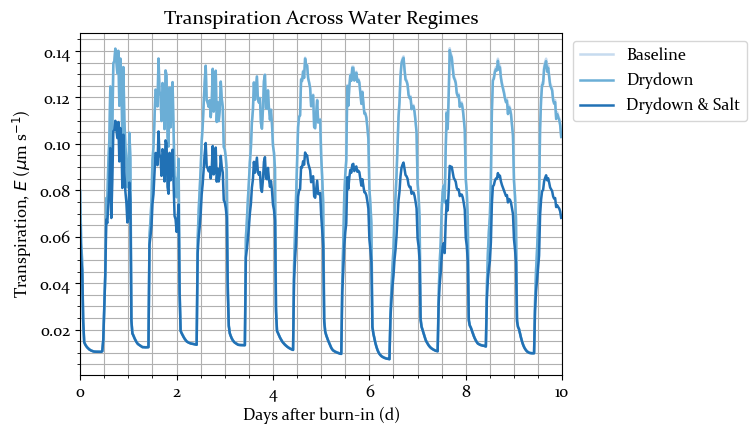

In [31]:
# Plot transpiration only after burn-in.
start_day_after_burn_in = 0

candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    candidate_lengths.append(len(out["ev"]))
n_plot = min(candidate_lengths)

max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0
post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_idx = int(np.searchsorted(post_burn_days, start_day_after_burn_in, side="left"))
time_plot = post_burn_days[plot_start_idx:]

scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    index = slice(max_burn_in + plot_start_idx, n_plot)
    ax.plot(time_plot, np.asarray(out["ev"])[index], linewidth=1.8, color=scenario_colors[name], label=label)

ax.set_title("Transpiration Across Water Regimes")
ax.set_ylabel(r"Transpiration, $E$ ($\mu$m s$^{-1}$)")
ax.set_xlabel("Days after burn-in (d)")
ax.set_xlim(0, post_burn_duration)
ax.minorticks_on()
ax.grid(visible=True, which="both", axis="both")
ax.legend(bbox_to_anchor=(1.005, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.86, 1])
fig.savefig(run_output_dir / "transpiration.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot: Potentials by Scenario

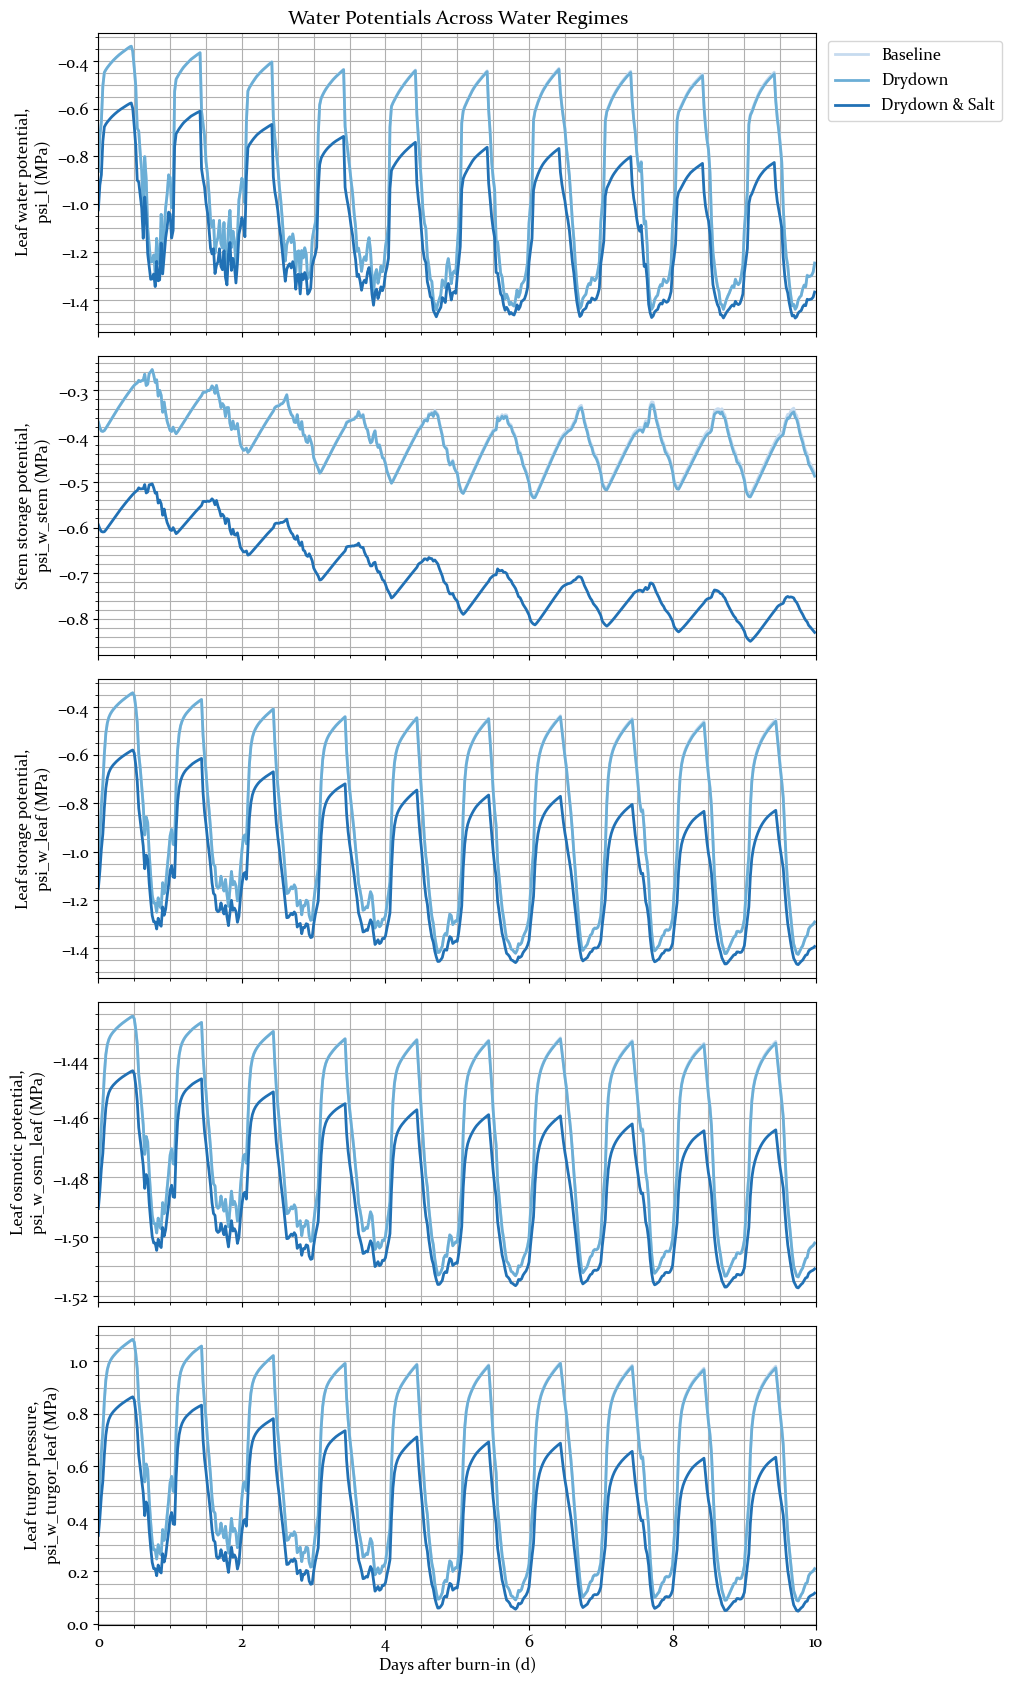

In [32]:
expected_steps = int(duration * 24 * 60 / timestepM)

candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    candidate_lengths.extend([
        len(out["psi_l"]),
        len(out["psi_w_stem"]),
        len(out["psi_w_leaf"]),
        len(out["psi_w_osm_leaf"]),
        len(out["psi_w_turgor_leaf"]),
    ])

n_plot = min(candidate_lengths)
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0
post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
time_plot = post_burn_days

scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

series_specs = [
    ("psi_l", "Leaf water potential,\npsi_l (MPa)"),
    ("psi_w_stem", "Stem storage potential,\npsi_w_stem (MPa)"),
    ("psi_w_leaf", "Leaf storage potential,\npsi_w_leaf (MPa)"),
    ("psi_w_osm_leaf", "Leaf osmotic potential,\npsi_w_osm_leaf (MPa)"),
    ("psi_w_turgor_leaf", "Leaf turgor pressure,\npsi_w_turgor_leaf (MPa)"),
]

fig, axes = plt.subplots(len(series_specs), 1, figsize=(12, 17), sharex=True)
for ax, (key, ylabel) in zip(axes, series_specs):
    for cfg in scenario_configs:
        name = cfg["name"]
        label = results_by_scenario[name]["label"]
        y = np.asarray(results_by_scenario[name]["output"][key])[max_burn_in:n_plot]
        ax.plot(time_plot, y, linewidth=2, color=scenario_colors[name], label=label)
    ax.set_ylabel(ylabel)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

axes[0].set_title("Water Potentials Across Water Regimes")
axes[-1].set_xlabel("Days after burn-in (d)")
axes[-1].set_xlim(0, post_burn_duration)
axes[0].legend(bbox_to_anchor=(1.005, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.86, 1])
fig.savefig(run_output_dir / "potentials_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot: Soil Moisture Flux by Scenario


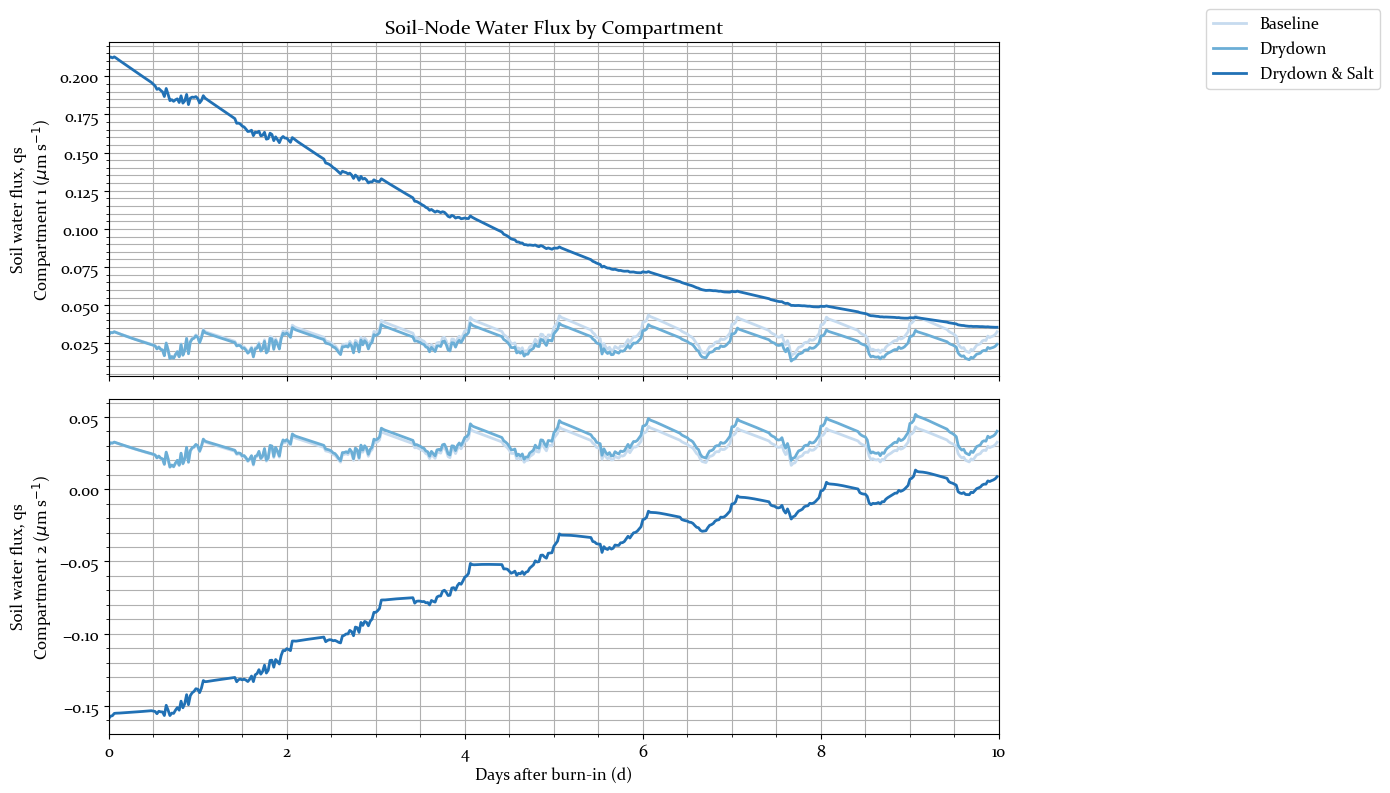

In [33]:
# Plot water fluxes from each soil compartment after burn-in.
scenarios_to_plot = [cfg["name"] for cfg in scenario_configs]

qs_arrays = {
    name: np.asarray(results_by_scenario[name]["output"]["qs"], dtype=float)
    for name in scenarios_to_plot
}
qs_by_compartment = {}
for name, qs_array in qs_arrays.items():
    qs_by_compartment[name] = qs_array if qs_array.shape[0] == num_compartments else qs_array.T

n_plot = min(qs_array.shape[1] for qs_array in qs_by_compartment.values())
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0
post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
time_plot = post_burn_days

fig, axes = plt.subplots(num_compartments, 1, figsize=(12, 4 * num_compartments), sharex=True)
if num_compartments == 1:
    axes = [axes]

scenario_colors = {
    name: scenario_palette[i % len(scenario_palette)]
    for i, name in enumerate(scenarios_to_plot)
}

for comp_idx, ax in enumerate(axes):
    for name in scenarios_to_plot:
        label = results_by_scenario[name]["label"]
        qs_comp = qs_by_compartment[name][comp_idx, max_burn_in:n_plot]
        ax.plot(time_plot, qs_comp, linewidth=2, color=scenario_colors[name], label=label)
    ax.set_ylabel(f"Soil water flux, qs\nCompartment {comp_idx + 1} ($\\mu$m s$^{{-1}}$)")
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

axes[0].set_title("Soil-Node Water Flux by Compartment")
axes[-1].set_xlabel("Days after burn-in (d)")
axes[-1].set_xlim(0, post_burn_duration)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.005, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.86, 1])
fig.savefig(run_output_dir / "soil_water_flux.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot: Stem and Leaf Water Content by Scenario

## Plot: Stomatal Conductance by Scenario

## Trial: Soil Water Potential Timeseries (Sand vs. Berger / Van Genuchten)

Drives a single soil compartment of each texture with the same transpiration flux (`qs`, taken from the S2 run) to compare the Van Genuchten retention curve (Berger) against the Clapp-Hornberger curve (Sand).

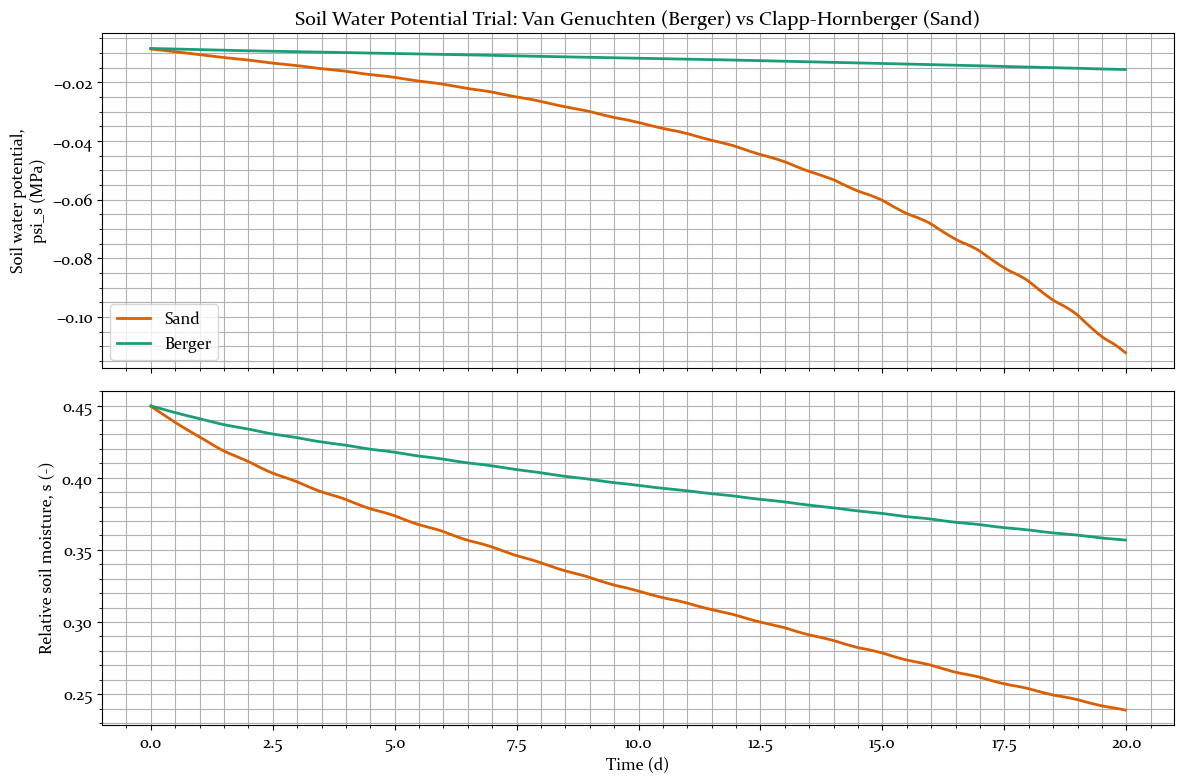

In [34]:
trial_qs = np.asarray(results_by_scenario["S2"]["output"]["qs"][0], dtype=float)
trial_zr = np.array([zr_arr[0]])
trial_s0 = np.array([s_init_arr[0]])
trial_cs0 = np.array([0.0])

trial_soils = {}
for tex_name, tex_cls in [("Sand", Sand), ("Berger", Berger)]:
    soil_trial = SaltySoilMultiple(
        stype=[tex_cls()],
        dynamics=[DrydownSoil()],
        zr=trial_zr,
        s=trial_s0.copy(),
        cs=trial_cs0.copy(),
    )
    for qs_val in trial_qs:
        soil_trial.update(dt, trial_zr, np.array([qs_val]))
    trial_soils[tex_name] = soil_trial

trial_days = np.arange(len(trial_qs)) * dt / 86400.0

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for tex_name, color in zip(trial_soils, ["#d95f02", "#1b9e77"]):
    trial_out = trial_soils[tex_name].output()
    ax1.plot(trial_days, trial_out["psi_s"][0], linewidth=2, color=color, label=tex_name)
    ax2.plot(trial_days, trial_out["s"][0], linewidth=2, color=color, label=tex_name)
ax1.set_ylabel("Soil water potential,\npsi_s (MPa)")
ax1.set_title("Soil Water Potential Trial: Van Genuchten (Berger) vs Clapp-Hornberger (Sand)")
ax1.minorticks_on()
ax1.grid(visible=True, which="both", axis="both")
ax1.legend()
ax2.set_ylabel("Relative soil moisture, s (-)")
ax2.set_xlabel("Time (d)")
ax2.minorticks_on()
ax2.grid(visible=True, which="both", axis="both")
fig.tight_layout()
fig.savefig(run_output_dir / "soil_psi_s_trial_sand_vs_berger.png", dpi=300, bbox_inches="tight")
plt.show()
